# 고객 이탈 예측

## 0. 요구사항 정의

- 목표: 고객 이탈 여부(Churn)에 영향을 줄 수 있는 요인 파악
- 출력: 각 변수의 분포, 상관관계, 결측 및 이상치 현황

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
from scipy import stats
import json
import sklearn
import re

#sklearn library
# 1.model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, KFold

# 2.preprocessing
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler


# 3.base setting
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
font = {'weight':'normal',
        'size':12}
plt.rc('font', **font)
sns.set(rc={"figure.dpi": 300, 'savefig.dpi': 300})
sns.set_context('notebook')
sns.set_style("ticks")
FIG_FONT = dict(weight="bold", color="#7f7f7f")
sns.set_palette('Spectral')



## 1. Data 확인

### 1-1. Load Data

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1-2. 데이터 구조 확인

In [3]:
df.shape

(7043, 21)

In [4]:
# 데이터 타입 확인
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# 수치형 데이터 확인
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# 문자형(범주형) 데이터 확인(T=전치)
df.describe(include=['object']).T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


### 1-3. 데이터 형변환

In [7]:
# 문자를 숫자형으로 변형 (errors -> 숫자로 바꿀수 없는 데이터를 NaN으로 강제 변경 후 숫자형태 변경)
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')

**(1) 숫자형 컬럼 → 변환 필요**
- `TotalCharges`, `MonthlyCharges` 같은 숫자형
- 빈 문자열 → NaN(Pandas 결측치)값 변환 필요
- 이유:
    - 평균, 합계 등 통계 계산 필요
    - 시각화 (히스토그램, 박스플롯)
    - 머신러닝 모델 입력

**(2)  범주형 컬럼 → 의미 파악 후 결정**
```
df = pd.DataFrame({
    'name': ['홍길동', '', '김철수'],
    'email': ['hong@naver.com', ' ', 'kim@gmail.com'],
    'phone': ['010-1234-5678', None, '010-9999-8888']
})
```
- 빈문자열의 의미?
    - 고객이 입력 안함 → NaN으로 변환
    - "선택 안함"이라는 의미 → '없음' 같은 값으로 대체

---

## 2. 데이터 EDA

### EDA 기본 내용
  1. (결측치) 각 피처(=컬럼)의 결측값 비율
  2. (이상치) 각 피처별 이상치 확인
  3. (unique) 각 피처의 unique값과 unique값별 빈도
  4. (기술통계) 각 피처의 기술통계 (평균값, 최대값, 최솟값, 최빈값, 분위수 등)
  5. (상관관계) 피처-피처, 피처-타겟 간 상관관계 매트릭스
  6. 히스토그램, bar graph, box plot 등 (인사이트 도출)
  7. 각 피처별 Information Value 등 확인

### 2-1. 결측치 탐색

In [8]:
# 결측치 개수와 비율 확인
missing_data = pd.DataFrame({
    '결측치_개수': df.isnull().sum(),
    '결측치_비율(%)': (df.isnull().sum() / len(df)) * 100
})

# 결측치가 있는 컬럼만 필터링
missing_data = missing_data[missing_data['결측치_개수'] > 0].sort_values('결측치_개수', ascending=False)

print("="*35)
print(missing_data)
print("="*35)


              결측치_개수  결측치_비율(%)
TotalCharges      11   0.156183


### 2-2. 이상치 탐색

In [9]:
# 수치형 컬럼 고유값 확인
col1 = 'SeniorCitizen'
col2 = 'tenure'

print(f"Unique values in {col1}: {df[col1].nunique()}")
print(f"Unique values in {col2}: {df[col2].nunique()}")


Unique values in SeniorCitizen: 2
Unique values in tenure: 73


======================== 이상치 분석 (IQR) ========================
               컬럼  이상치_개수  이상치_비율(%)      하한선      상한선
0   SeniorCitizen    1142      16.21     0.00     0.00
1          tenure       0       0.00   -60.00   124.00
2  MonthlyCharges       0       0.00   -46.02   171.38
3    TotalCharges       0       0.00 -4688.48  8884.67


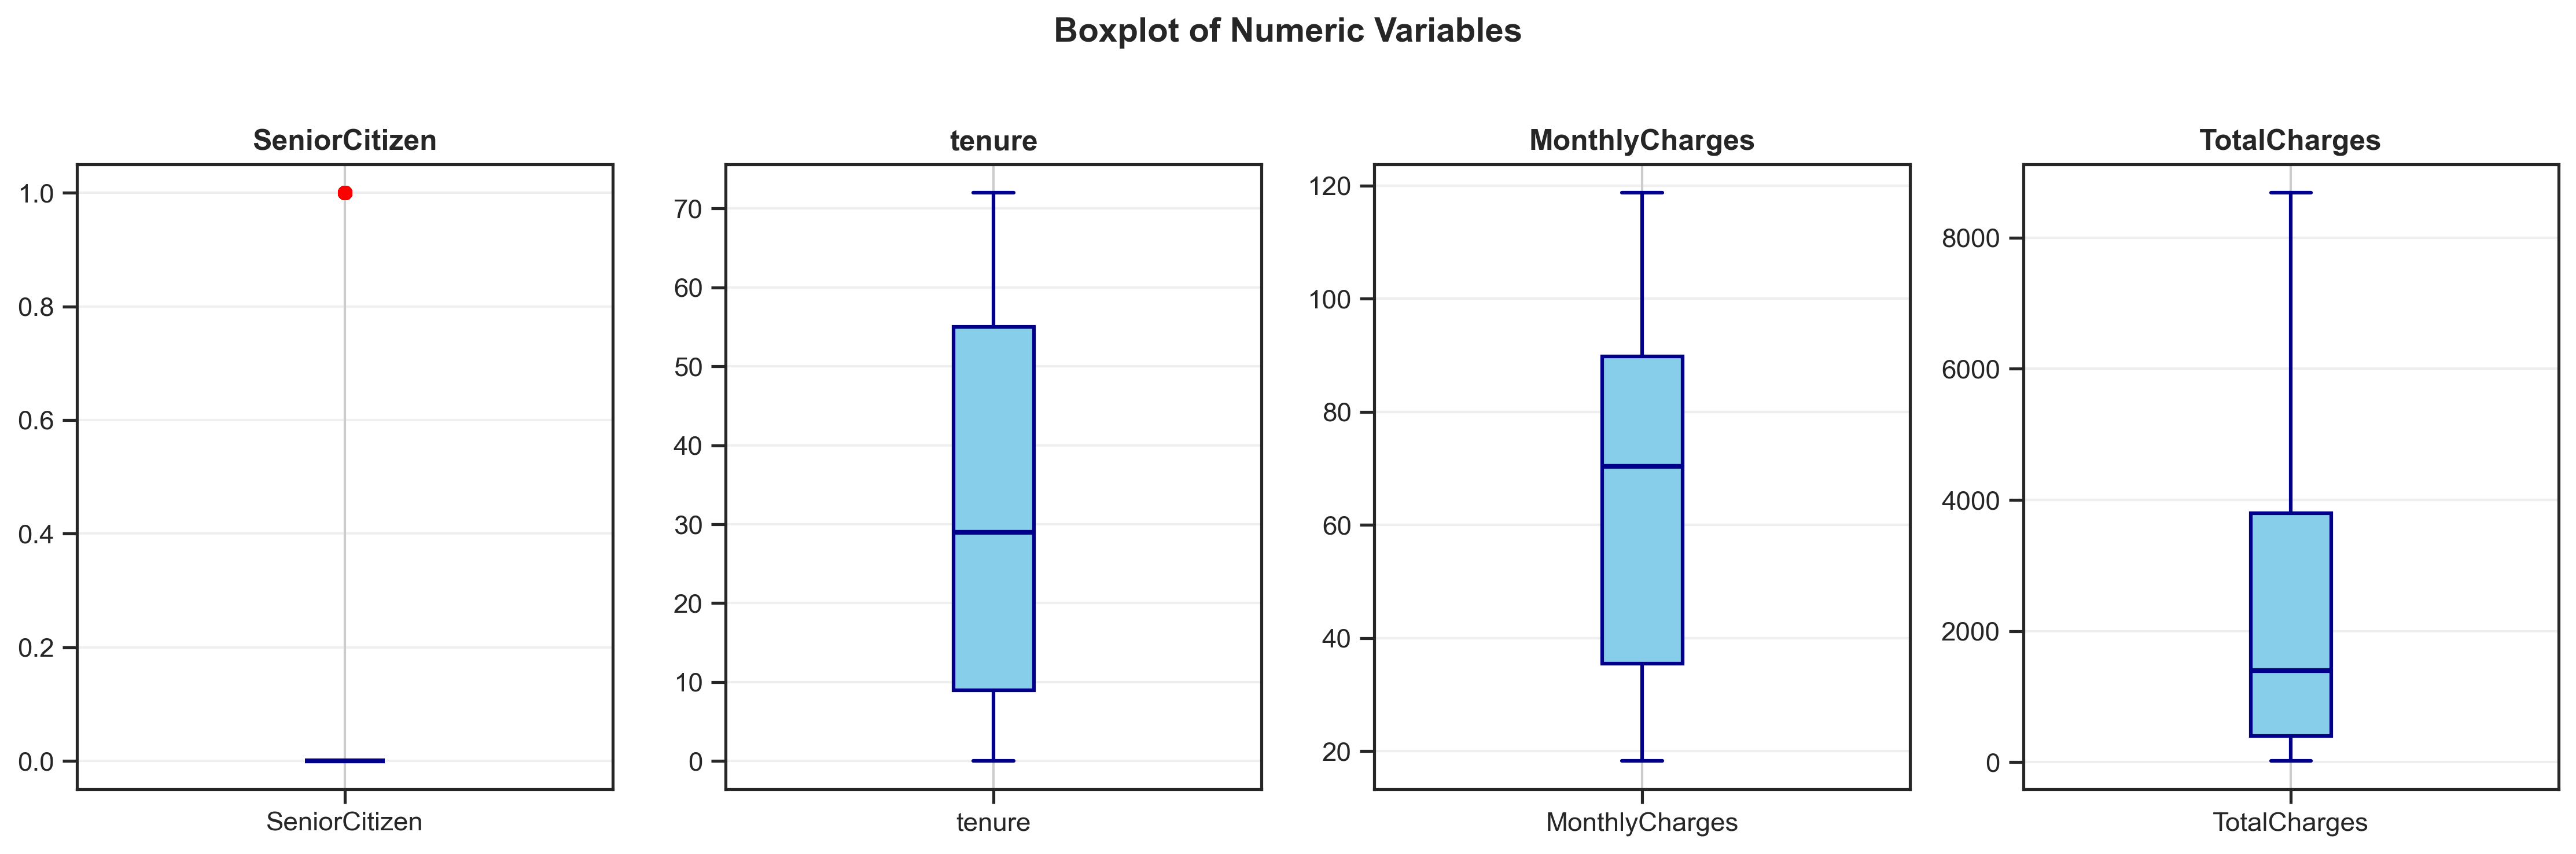

In [10]:
# 수치형 컬럼만 선택
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("======================== 이상치 분석 (IQR) ========================")

outliers_info = []

for col in numeric_cols:
    # IQR 계산
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # 이상치 범위 계산 (1.5 * IQR)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 이상치 개수 계산
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(df)) * 100
    
    outliers_info.append({
        '컬럼': col,
        '이상치_개수': outlier_count,
        '이상치_비율(%)': round(outlier_pct, 2),
        '하한선': round(lower_bound, 2),
        '상한선': round(upper_bound, 2)
    })

outliers_df = pd.DataFrame(outliers_info)
print(outliers_df)
print("=================================================================")

# 시각화: Box Plot으로 이상치 확인
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 5))

for idx, col in enumerate(numeric_cols):
    ax = axes[idx] if len(numeric_cols) > 1 else axes
    bp = df.boxplot(column=col, ax=ax, patch_artist=True, return_type='dict')
    
    # 박스 색상을 파란색으로 변경
    for box in bp['boxes']:
        box.set_facecolor('skyblue')
        box.set_edgecolor('darkblue')
        box.set_linewidth(1.5)
    
    # 중앙선을 진한 파란색으로
    for median in bp['medians']:
        median.set_color('darkblue')
        median.set_linewidth(2)
    
    # 수염(whiskers)을 파란색으로
    for whisker in bp['whiskers']:
        whisker.set_color('darkblue')
        whisker.set_linewidth(1.5)
    
    # 캡(caps)을 파란색으로
    for cap in bp['caps']:
        cap.set_color('darkblue')
        cap.set_linewidth(1.5)
    
    # 이상치는 빨간색 점으로 표시
    for flier in bp['fliers']:
        flier.set_markeredgecolor('red')
        flier.set_markerfacecolor('red')
        flier.set_marker('o')
        flier.set_markersize(5)
    
    ax.set_title(f'{col}', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Boxplot of Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [11]:
# SeniorCitizen 컬렴 형변환(수치형 -> 범주형)
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'Not Senior', 1: 'Senior'})
print(df['SeniorCitizen'].dtype)

object


In [12]:
#df.info()

### 2-3. Unique 값과 빈도 분석



In [13]:
# 범주형 컬럼 선택 (customerID 제외)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if 'customerID' in categorical_cols:
    categorical_cols.remove('customerID')

print("=" * 80)
print("Unique Values and Frequency of Categorical Variables".center(80))
print("=" * 80)

unique_info = []

for col in categorical_cols:
    unique_count = df[col].nunique()
    most_common = df[col].value_counts().head(1)
    
    unique_info.append({
        '컬럼': col,
        'Unique_개수': unique_count,
        '최빈값': most_common.index[0],
        '최빈값_빈도': most_common.values[0],
        '최빈값_비율(%)': round((most_common.values[0] / len(df)) * 100, 2)
    })

unique_df = pd.DataFrame(unique_info)
print(unique_df)



              Unique Values and Frequency of Categorical Variables              
                  컬럼  Unique_개수               최빈값  최빈값_빈도  최빈값_비율(%)
0             gender          2              Male    3555      50.48
1      SeniorCitizen          2        Not Senior    5901      83.79
2            Partner          2                No    3641      51.70
3         Dependents          2                No    4933      70.04
4       PhoneService          2               Yes    6361      90.32
5      MultipleLines          3                No    3390      48.13
6    InternetService          3       Fiber optic    3096      43.96
7     OnlineSecurity          3                No    3498      49.67
8       OnlineBackup          3                No    3088      43.84
9   DeviceProtection          3                No    3095      43.94
10       TechSupport          3                No    3473      49.31
11       StreamingTV          3                No    2810      39.90
12   StreamingMovies  

### 2-4. 기술통계 분석


In [14]:
# 기본 기술통계
print("============================== 수치형 변수 기술통계 ==============================\n")
print(df.describe().T)

# 추가 통계량 (중앙값, 최빈값, 왜도, 첨도)
print("\n\n======================= 추가 통계량 ========================\n")

advanced_stats = []

# 수치형 컬럼 재정의 (SeniorCitizen이 object로 변환되었으므로)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    stats_dict = {
        '컬럼': col,
        '중앙값': round(df[col].median(), 2),
        '왜도(Skewness)': round(df[col].skew(), 2),
        '첨도(Kurtosis)': round(df[col].kurtosis(), 2)
    }
    advanced_stats.append(stats_dict)

stats_df = pd.DataFrame(advanced_stats)
print(stats_df.to_string(index=False))


============================== 수치형 변수 기술통계 ==============================

                 count         mean          std    min     25%       50%  \
tenure          7043.0    32.371149    24.559481   0.00    9.00    29.000   
MonthlyCharges  7043.0    64.761692    30.090047  18.25   35.50    70.350   
TotalCharges    7032.0  2283.300441  2266.771362  18.80  401.45  1397.475   

                      75%      max  
tenure            55.0000    72.00  
MonthlyCharges    89.8500   118.75  
TotalCharges    3794.7375  8684.80  


======================= 추가 통계량 ========================

            컬럼     중앙값  왜도(Skewness)  첨도(Kurtosis)
        tenure   29.00          0.24         -1.39
MonthlyCharges   70.35         -0.22         -1.26
  TotalCharges 1397.47          0.96         -0.23


### 2-5. 상관관계 분석


========================== 상관관계 매트릭스 ===========================

                  tenure  MonthlyCharges  TotalCharges     Churn
tenure          1.000000        0.247900      0.825880 -0.352229
MonthlyCharges  0.247900        1.000000      0.651065  0.193356
TotalCharges    0.825880        0.651065      1.000000 -0.199484
Churn          -0.352229        0.193356     -0.199484  1.000000


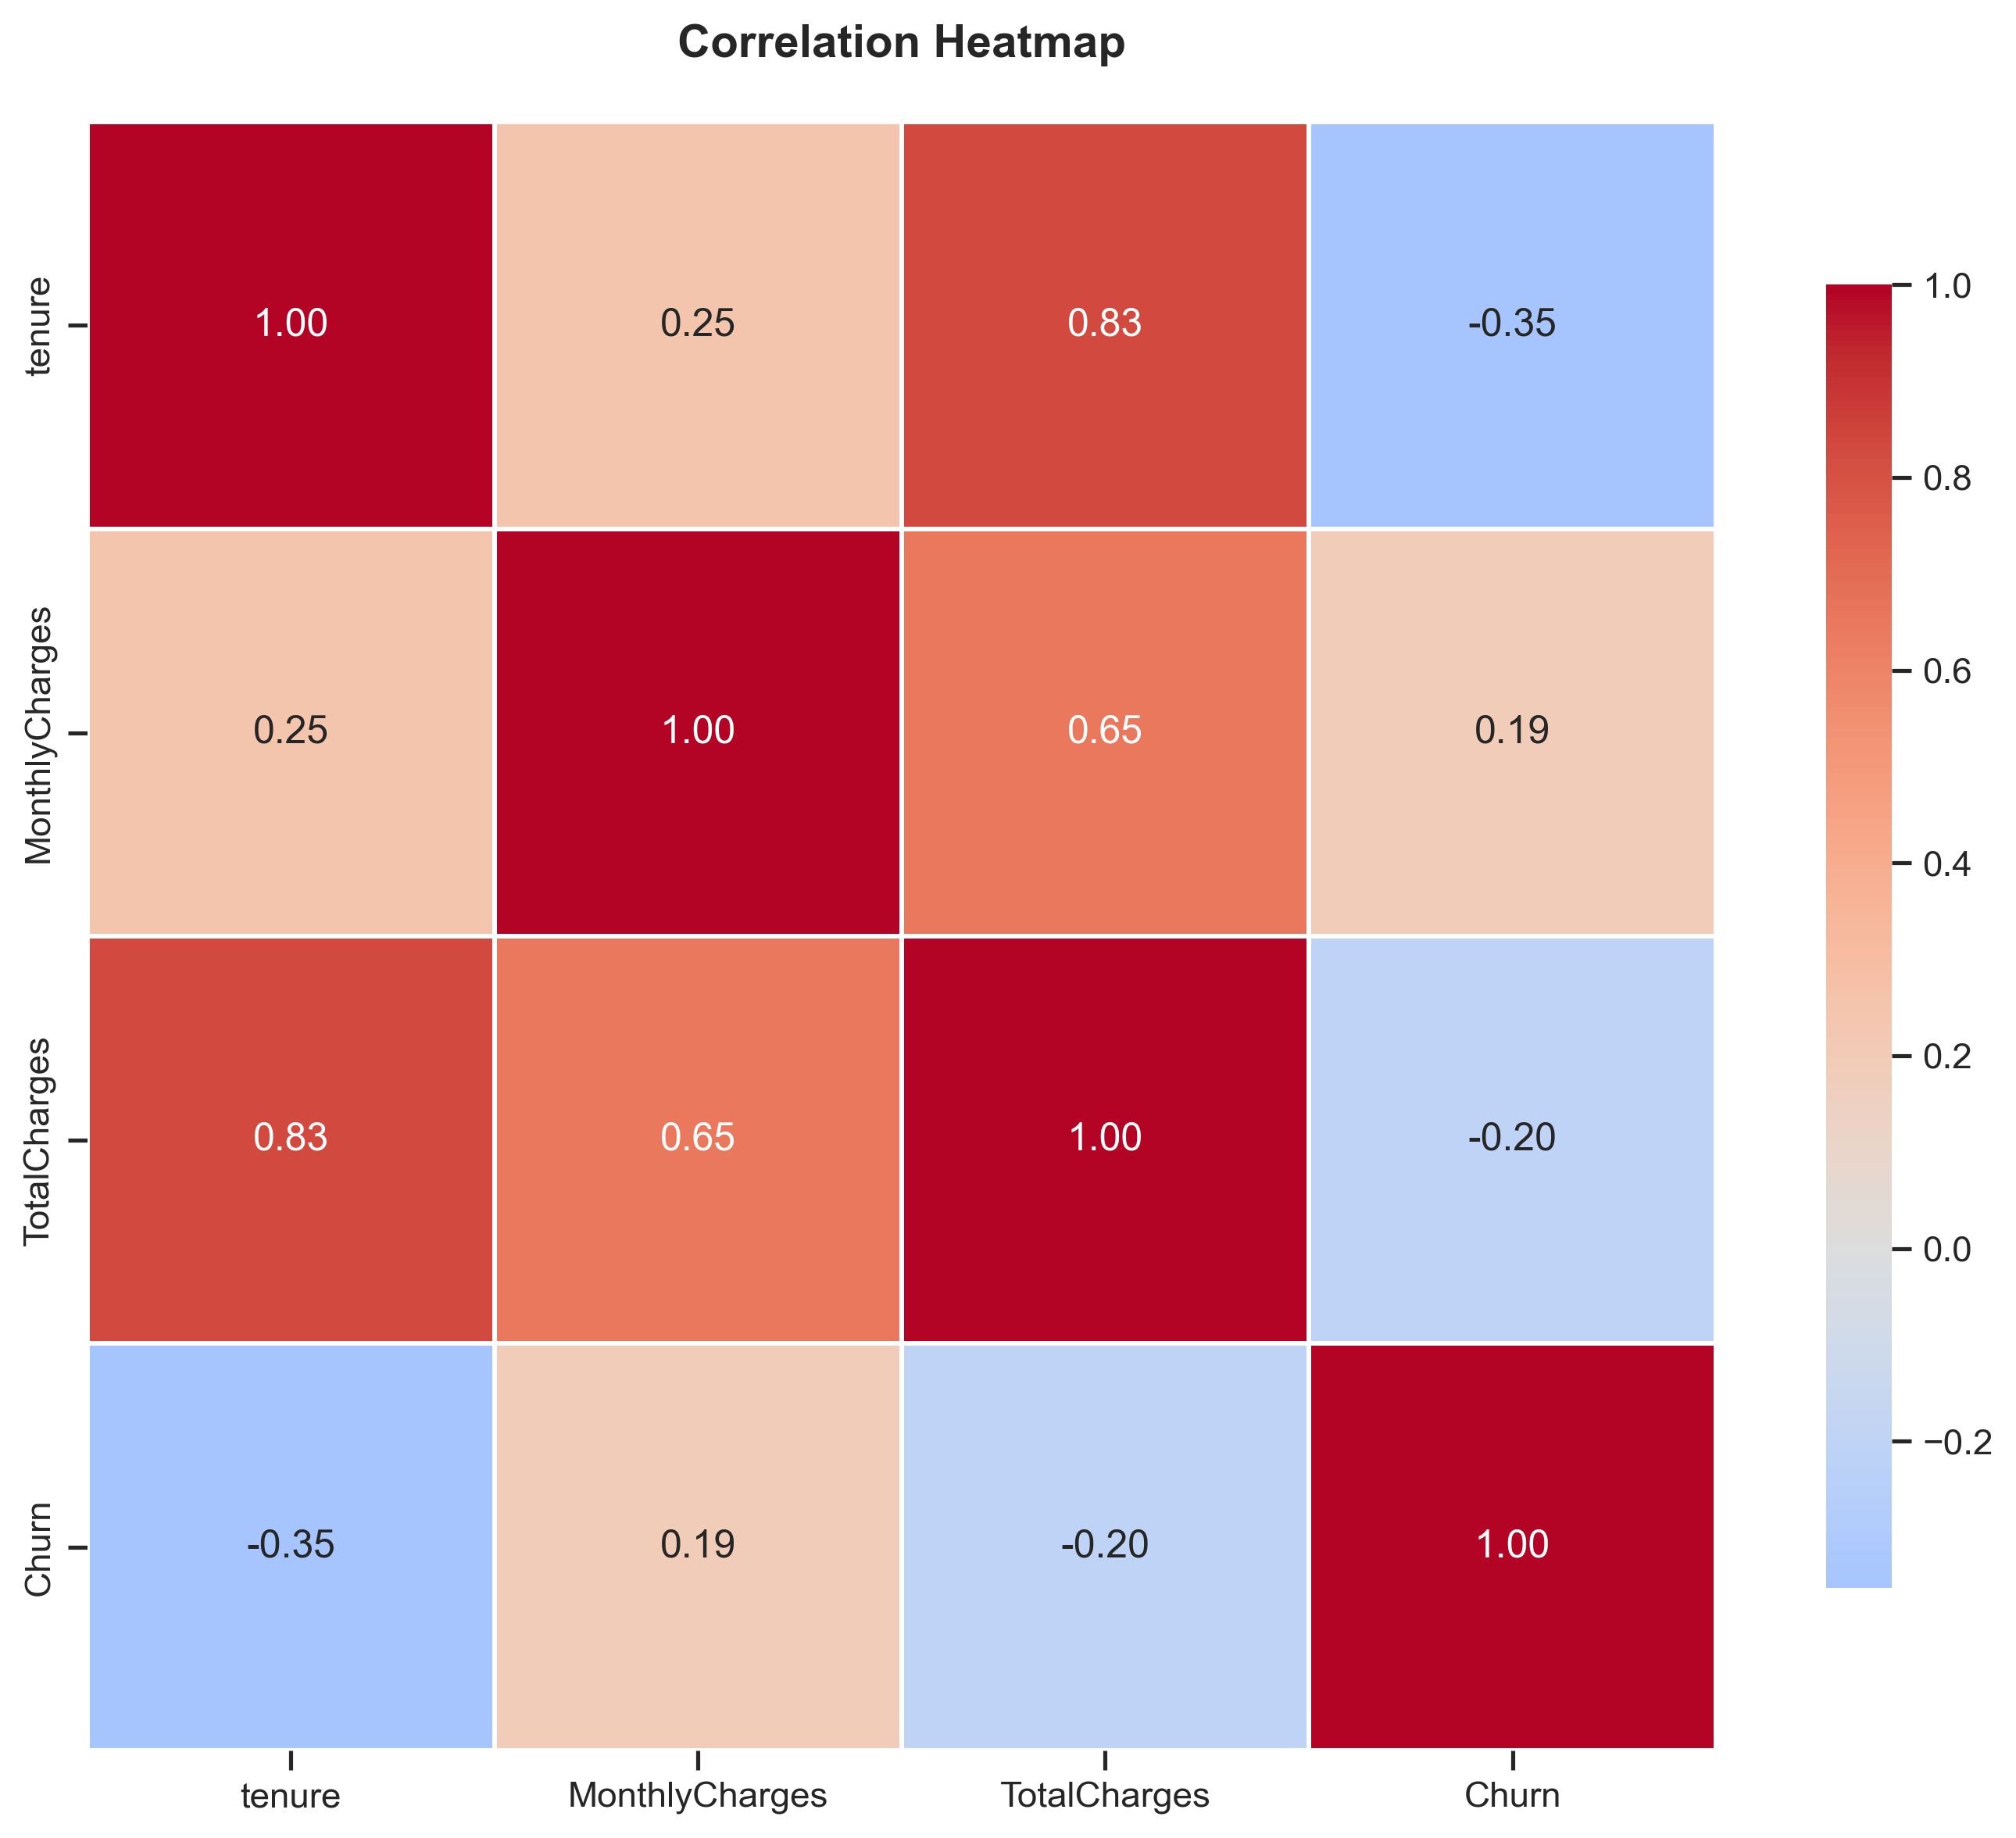

In [15]:
# Churn을 숫자로 변환 (상관관계 계산을 위해)
df_temp = df.copy()
df_temp['Churn'] = df_temp['Churn'].map({'Yes': 1, 'No': 0})

# 수치형 컬럼 + Churn_binary
correlation_cols = numeric_cols + ['Churn']
correlation_matrix = df_temp[correlation_cols].corr()

print("========================== 상관관계 매트릭스 ===========================\n")
print(correlation_matrix)

# 상관관계 히트맵
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


### 2-6. 분포 시각화 (히스토그램, 막대그래프, 박스플롯)


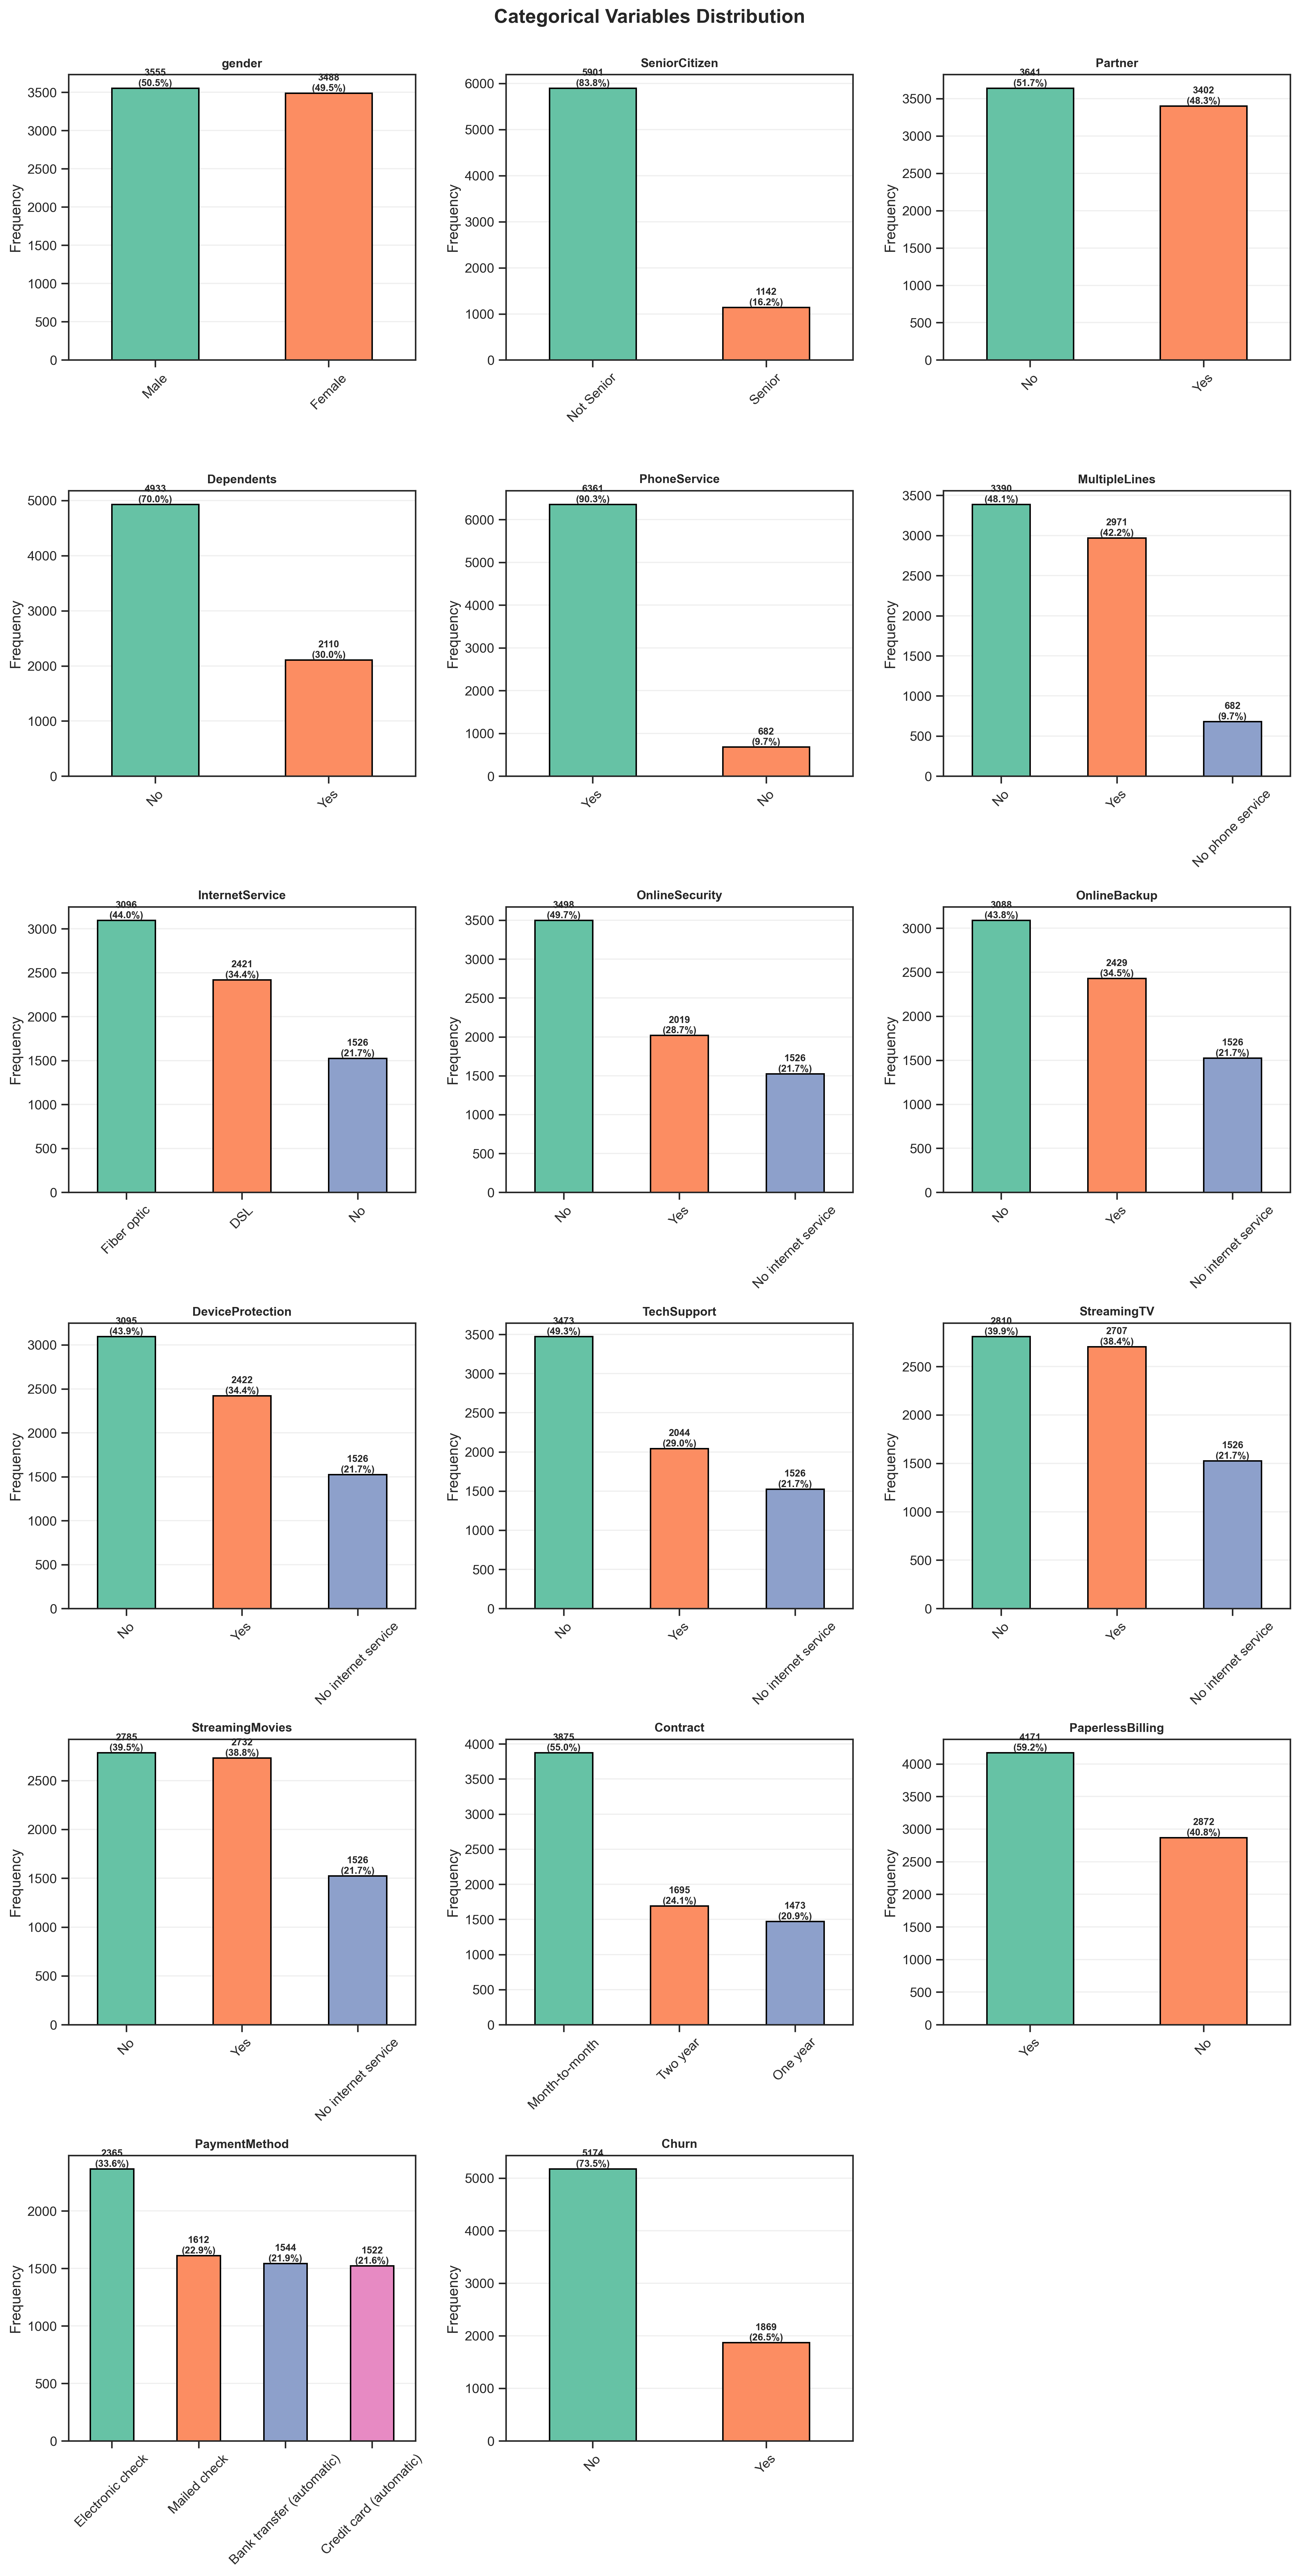

In [16]:
# 범주형 컬럼별 바그래프
fig, axes = plt.subplots(6, 3, figsize=(15, 30))
axes = axes.flatten()

# 컬러맵 설정
colors = plt.cm.Set2.colors

for idx, col in enumerate(categorical_cols[:17]):
    ax = axes[idx]
    
    # 빈도수와 비율 계산
    value_counts = df[col].value_counts()
    
    # 막대마다 다른 색상 적용
    bar_colors = [colors[i % len(colors)] for i in range(len(value_counts))]
    
    # 막대그래프
    value_counts.plot(kind='bar', ax=ax, color=bar_colors, edgecolor='black', linewidth=1.2)
    
    # Set title
    ax.set_title(f'{col}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Frequency')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    
    # 막대 위에 숫자와 비율 표시
    for i, (category, value) in enumerate(value_counts.items()):
        pct = (value / len(df)) * 100
        ax.text(i, value, f'{value}\n({pct:.1f}%)', 
                ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    ax.grid(axis='y', alpha=0.3)

# 빈 subplot 삭제
for idx in range(len(categorical_cols[:17]), len(axes)):
    fig.delaxes(axes[idx])

# Overall title
plt.suptitle('Categorical Variables Distribution', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

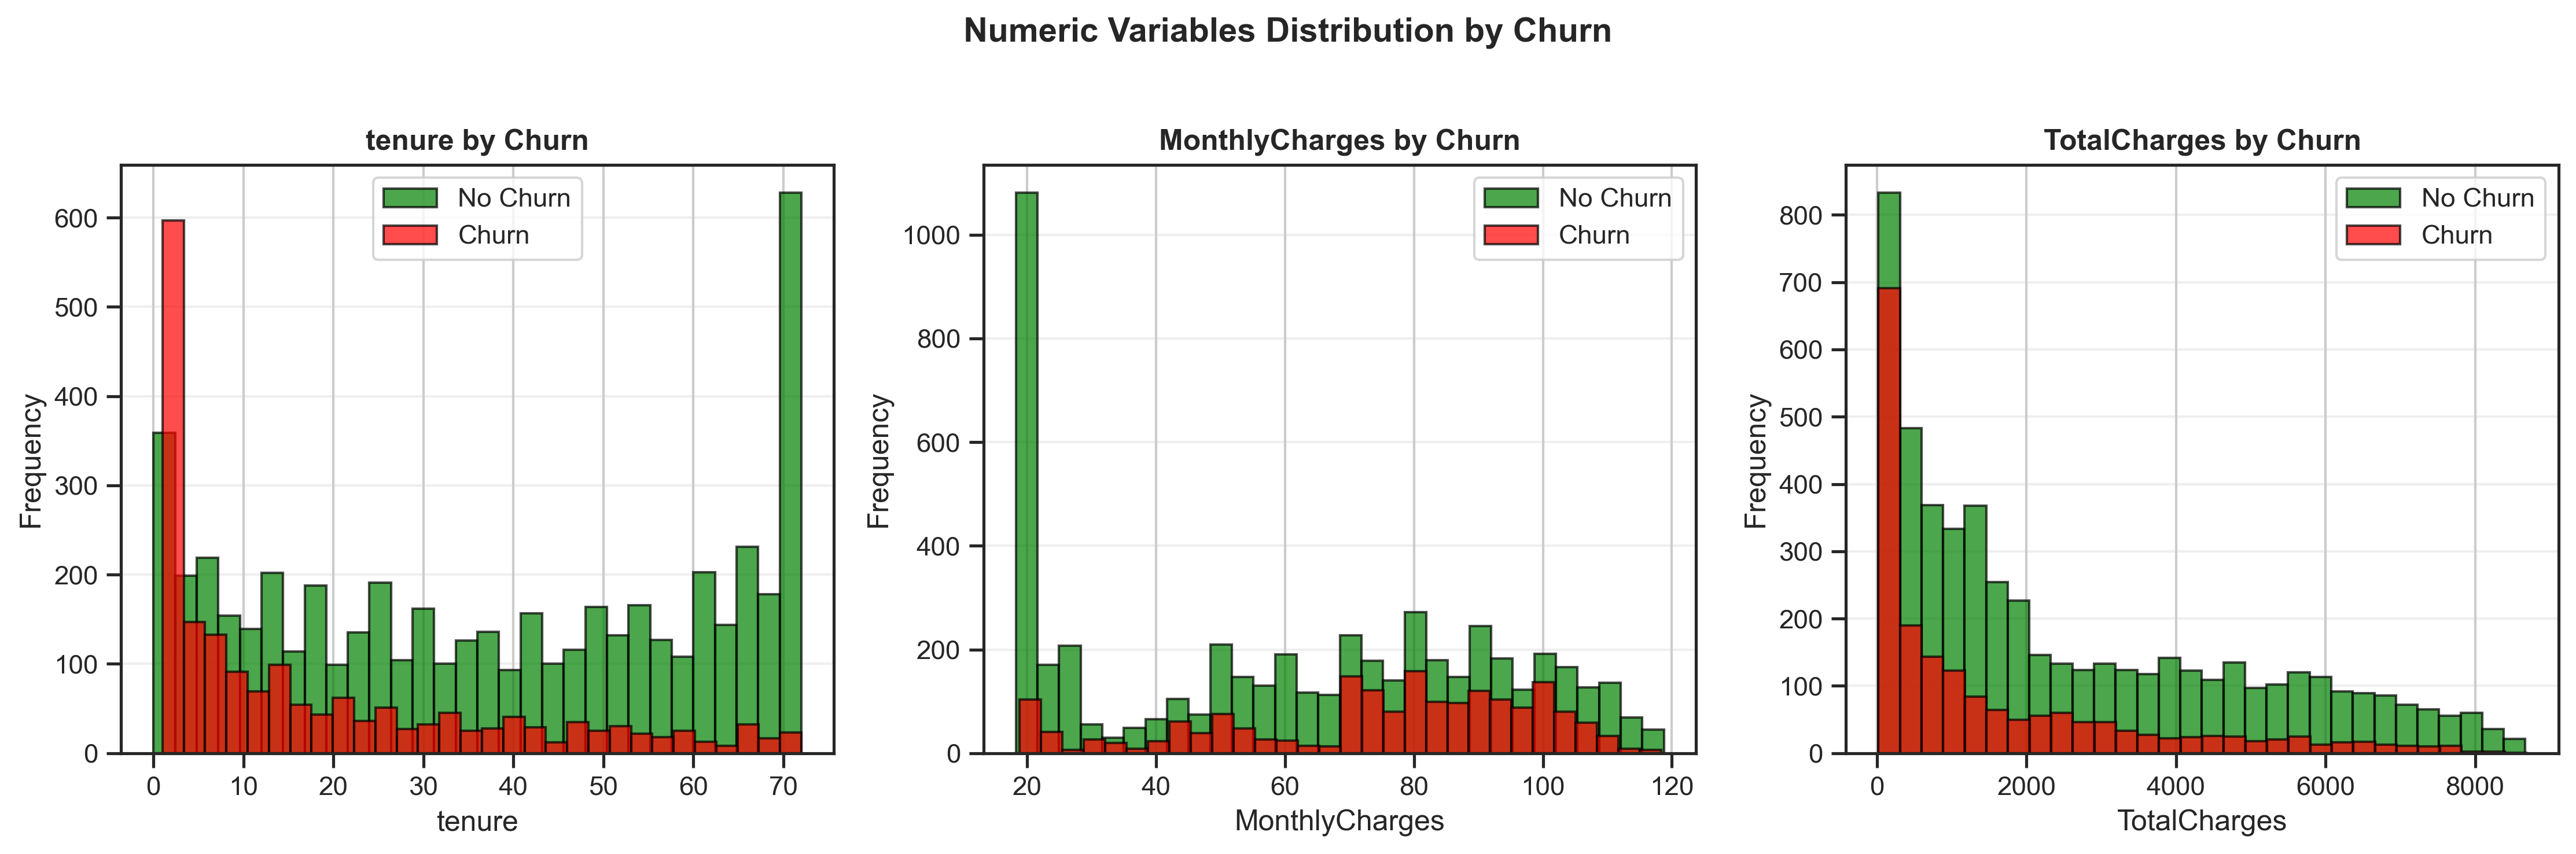

In [17]:
# 수치형 변수와 Churn의 관계 (히스토그램)
# 수치형 컬럼 재확인
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 5))
if len(numeric_cols) == 1:
    axes = [axes]

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    
    # Churn별로 히스토그램 그리기
    df[df['Churn'] == 'No'][col].hist(ax=ax, bins=30, alpha=0.7, label='No Churn', 
                                       color='green', edgecolor='black')
    df[df['Churn'] == 'Yes'][col].hist(ax=ax, bins=30, alpha=0.7, label='Churn', 
                                         color='red', edgecolor='black')
    
    ax.set_title(f'{col} by Churn', fontweight='bold', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Numeric Variables Distribution by Churn', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

/var/folders/4p/v982z_3d5fq0bcnhx19tlc4r0000gn/T/ipykernel_41175/2557600318.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_no_churn, data_churn],
/var/folders/4p/v982z_3d5fq0bcnhx19tlc4r0000gn/T/ipykernel_41175/2557600318.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_no_churn, data_churn],
/var/folders/4p/v982z_3d5fq0bcnhx19tlc4r0000gn/T/ipykernel_41175/2557600318.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_no_churn, data_churn],


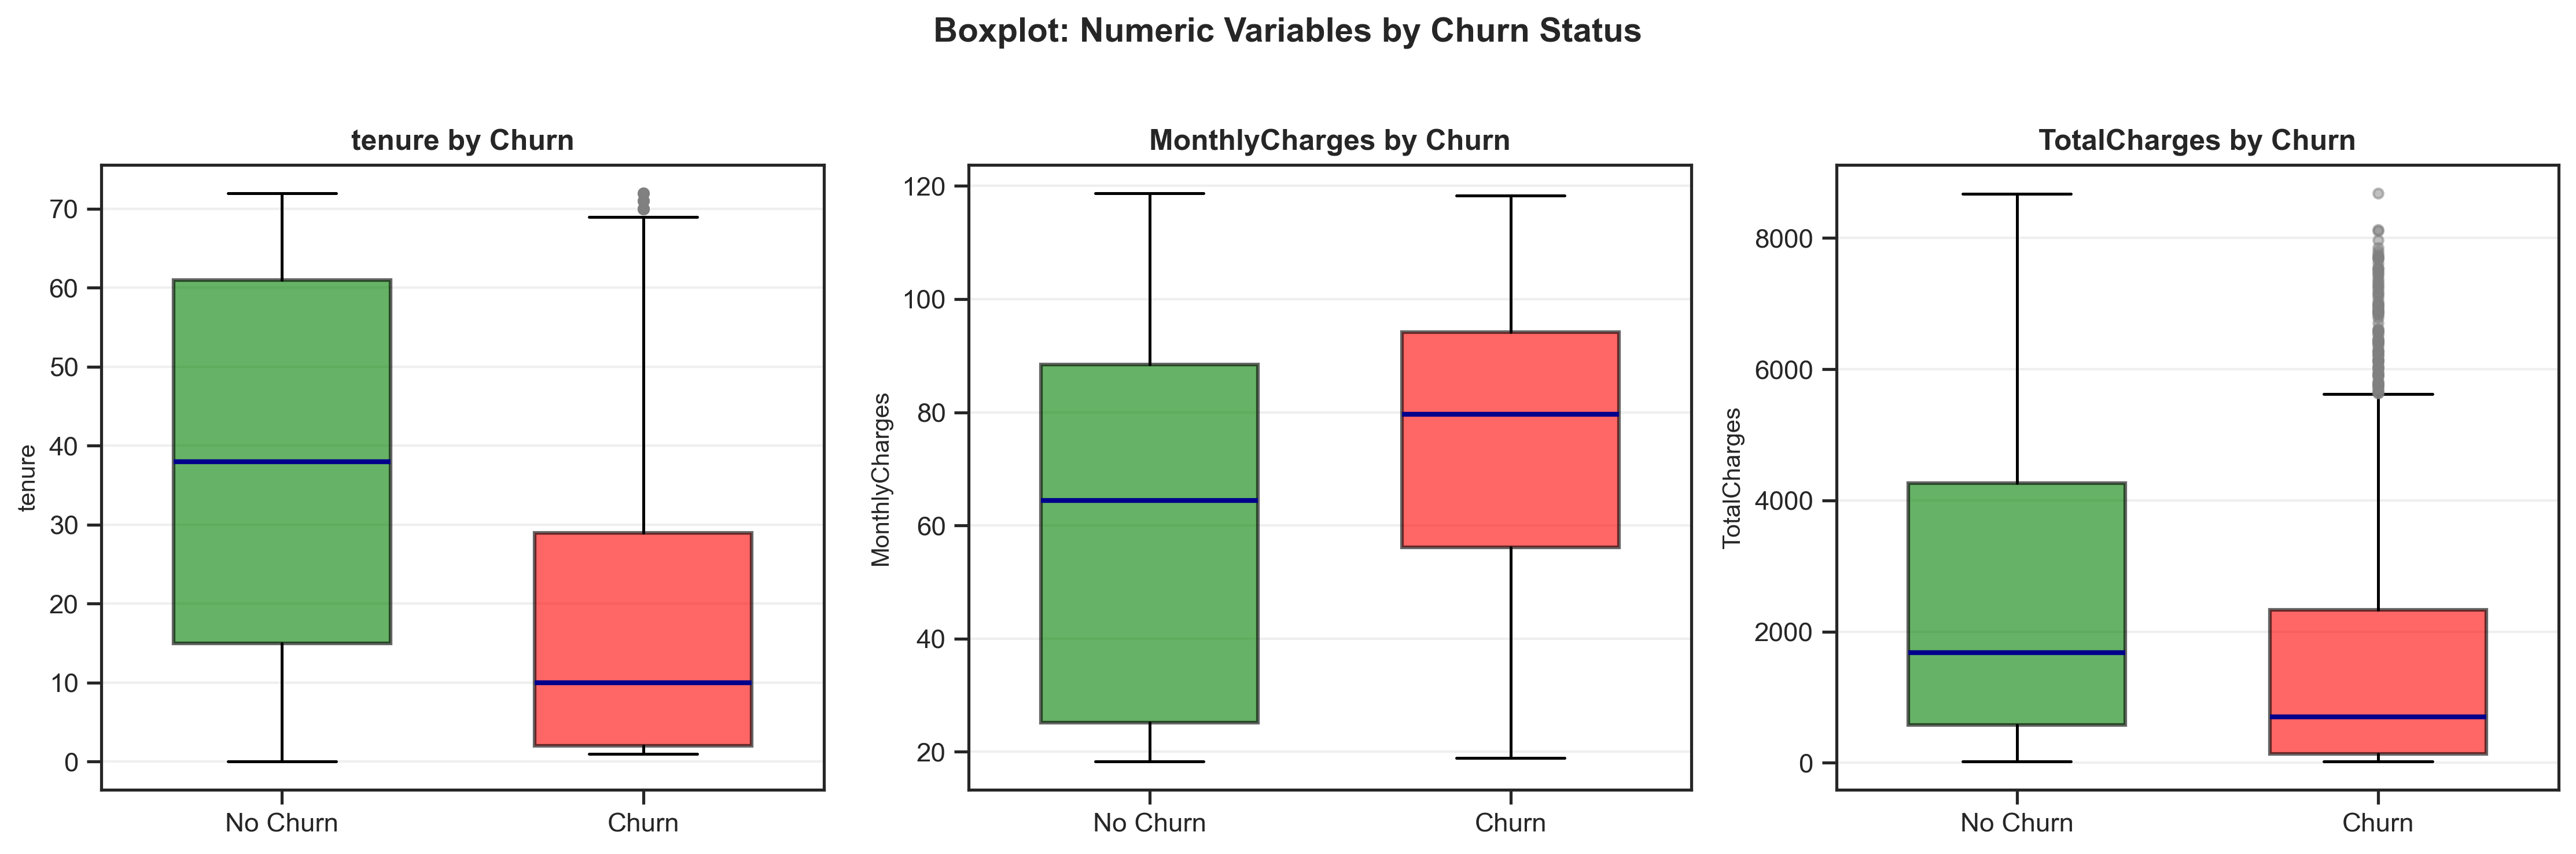

In [18]:
# 수치형 변수의 박스플롯
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 5))
if len(numeric_cols) == 1:
    axes = [axes]

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    
    # Churn별 데이터 분리
    data_no_churn = df[df['Churn'] == 'No'][col].dropna()
    data_churn = df[df['Churn'] == 'Yes'][col].dropna()
    
    # 박스플롯
    bp = ax.boxplot([data_no_churn, data_churn], 
                     labels=['No Churn', 'Churn'],
                     patch_artist=True,
                     widths=0.6)
    
    # 색상 설정
    colors = ['green', 'red']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.5)
    
    # 중앙선
    for median in bp['medians']:
        median.set_color('darkblue')
        median.set_linewidth(2)
    
    # 수염
    for whisker in bp['whiskers']:
        whisker.set_color('black')
        whisker.set_linewidth(1.2)
    
    # 캡
    for cap in bp['caps']:
        cap.set_color('black')
        cap.set_linewidth(1.2)
    
    # 이상치
    for flier in bp['fliers']:
        flier.set_markeredgecolor('gray')
        flier.set_markerfacecolor('gray')
        flier.set_marker('o')
        flier.set_markersize(4)
        flier.set_alpha(0.5)
    
    ax.set_title(f'{col} by Churn', fontweight='bold', fontsize=12)
    ax.set_ylabel(col, fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Boxplot: Numeric Variables by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

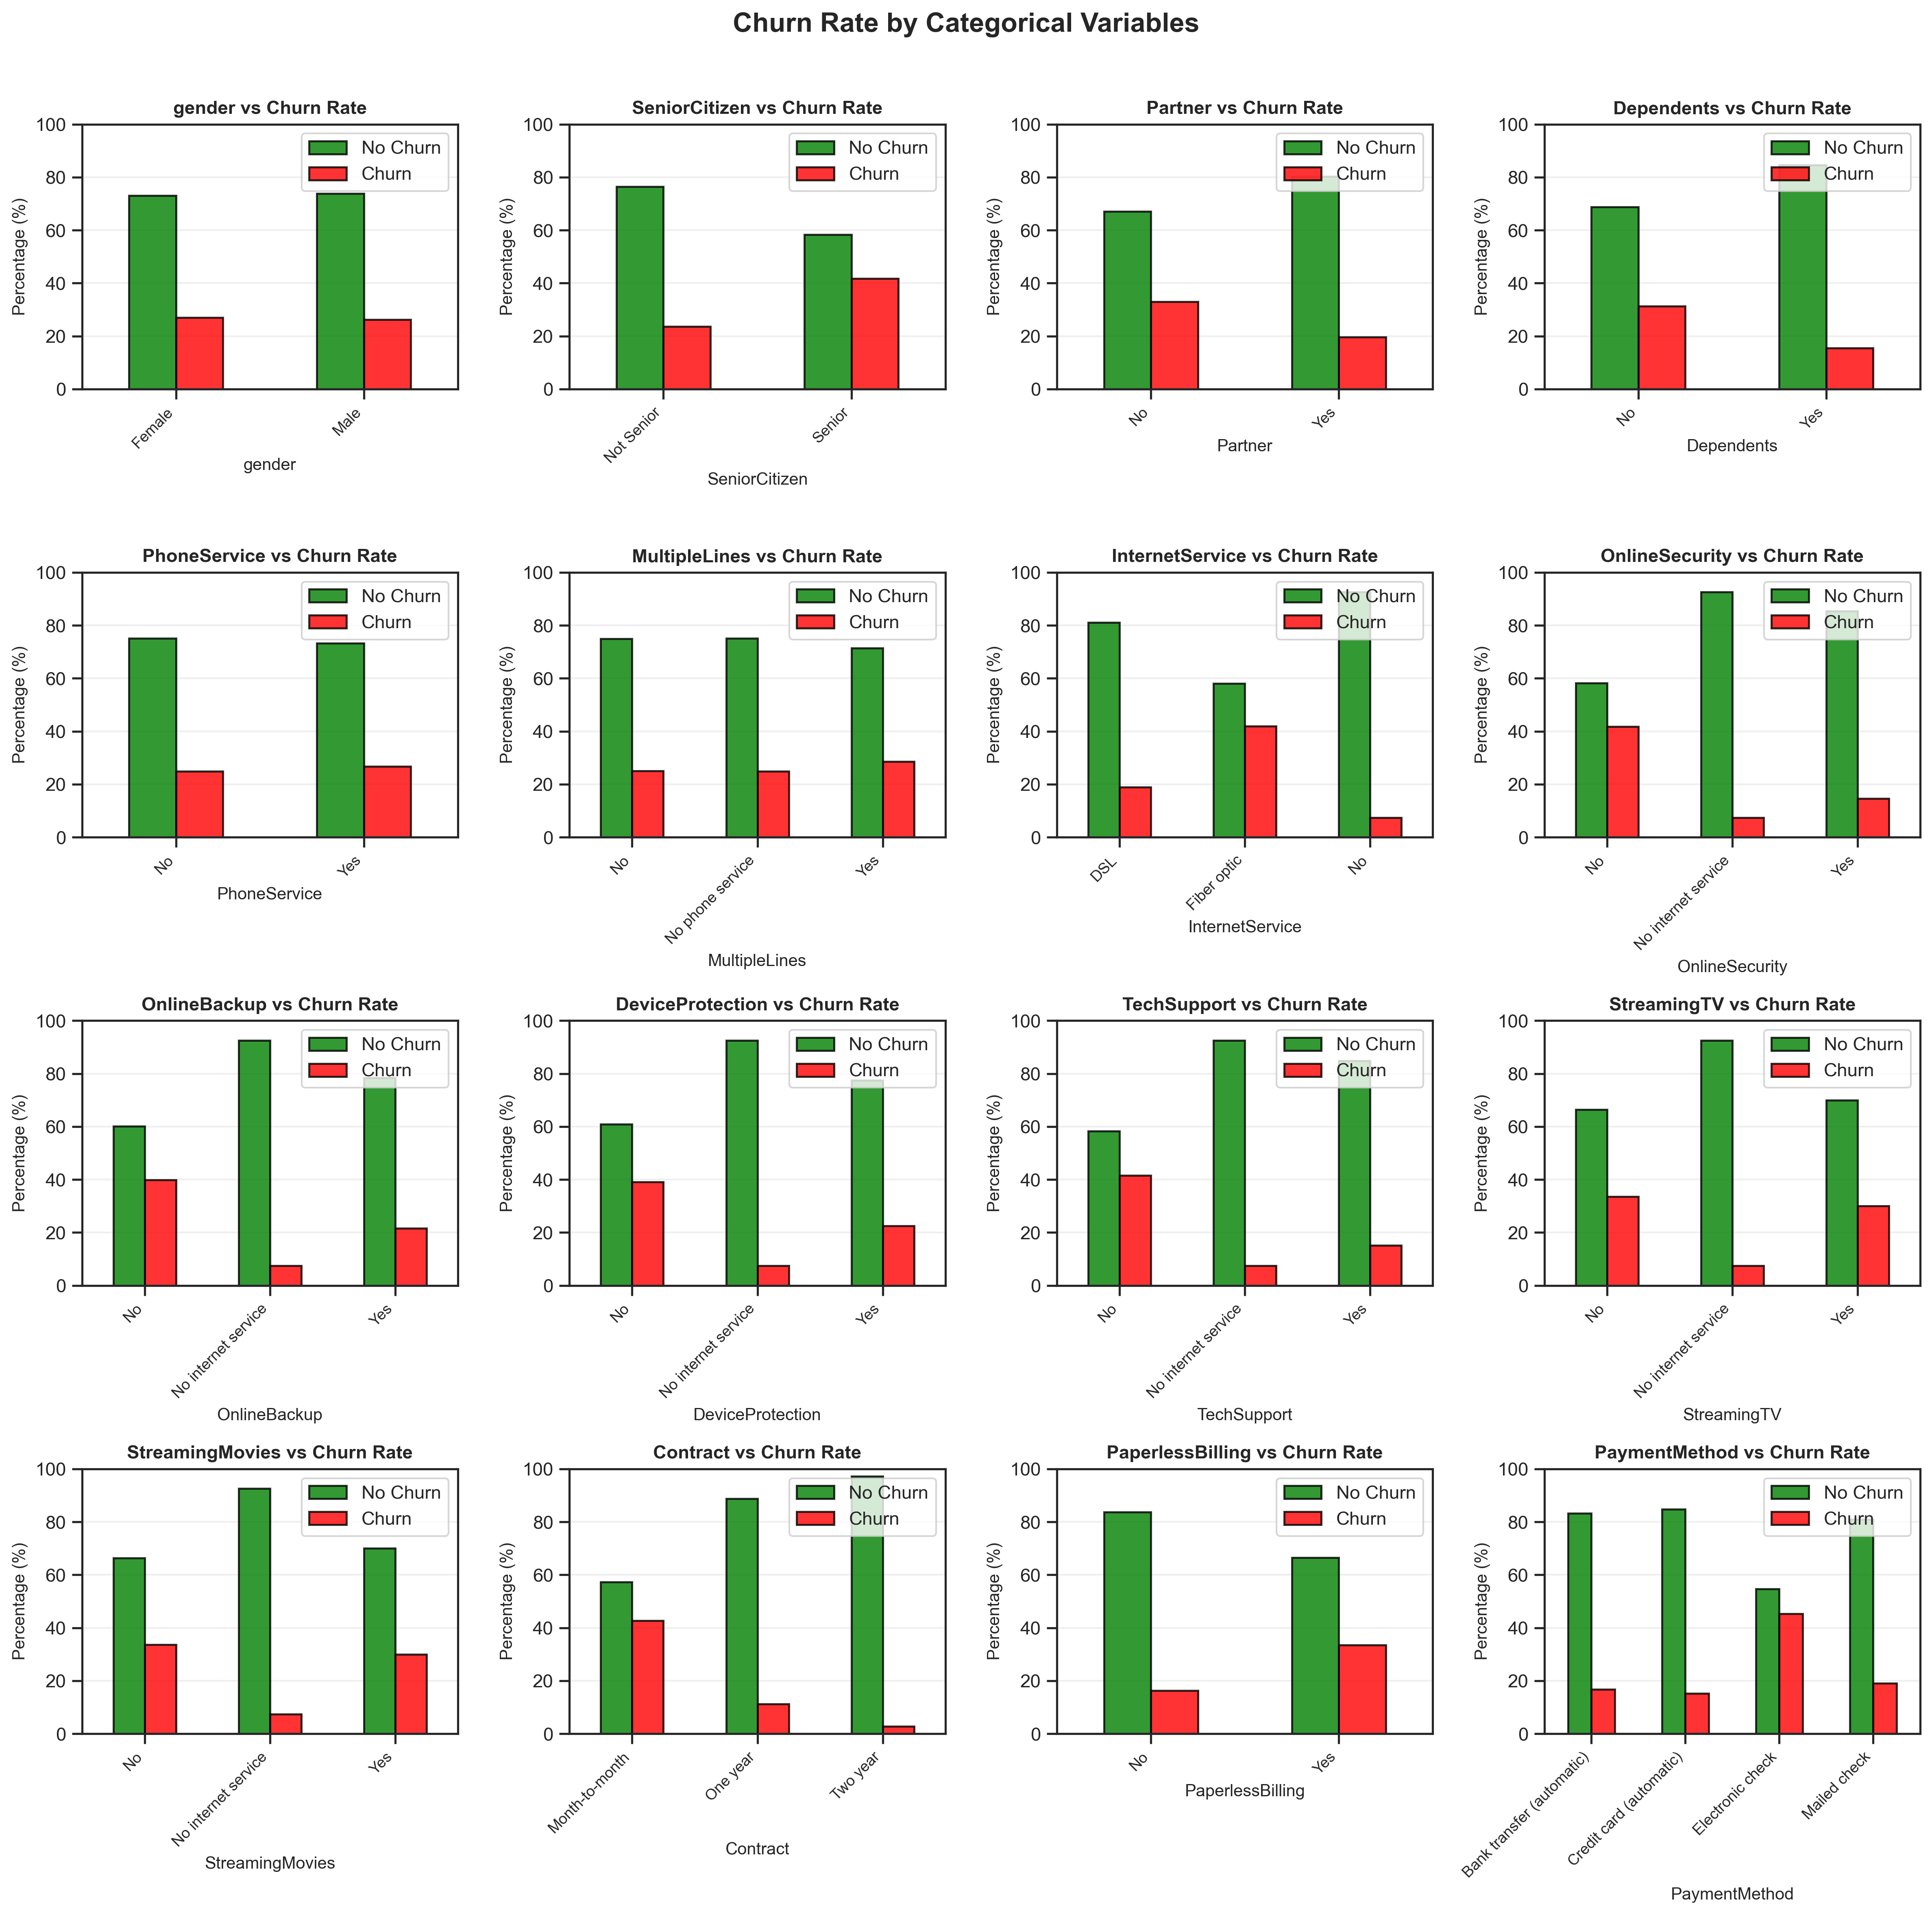

In [19]:
# 범주형 변수와 Churn의 관계 (막대그래프)
# 범주형 컬럼 선택 (Churn 제외)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if 'customerID' in categorical_cols:
    categorical_cols.remove('customerID')
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')

# 범주형 변수만 선택
important_cats = categorical_cols[:17]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for idx, col in enumerate(important_cats):
    ax = axes[idx]
    
    # 교차표: 각 범주별 Churn 비율 계산
    crosstab = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    
    # 막대그래프 (Stacked bar chart)
    crosstab.plot(kind='bar', ax=ax, stacked=False, 
                  color=['green', 'red'], 
                  edgecolor='black', linewidth=1.2, alpha=0.8)
    
    ax.set_title(f'{col} vs Churn Rate', fontweight='bold', fontsize=11)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Percentage (%)', fontsize=10)
    ax.legend(['No Churn', 'Churn'], loc='upper right')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 100)

plt.suptitle('Churn Rate by Categorical Variables', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### 2-7. Information Value (IV) 분석

=== Information Value (변수 중요도) ===

                  변수      IV   타입
16          Contract  1.2386  범주형
0             tenure  0.8237  수치형
10    OnlineSecurity  0.7178  범주형
13       TechSupport  0.6996  범주형
9    InternetService  0.6180  범주형
11      OnlineBackup  0.5286  범주형
12  DeviceProtection  0.4997  범주형
18     PaymentMethod  0.4571  범주형
15   StreamingMovies  0.3814  범주형
14       StreamingTV  0.3805  범주형
1     MonthlyCharges  0.3647  수치형
2       TotalCharges  0.3376  수치형
17  PaperlessBilling  0.2031  범주형
6         Dependents  0.1555  범주형
5            Partner  0.1187  범주형
4      SeniorCitizen  0.1056  범주형
8      MultipleLines  0.0082  범주형
7       PhoneService  0.0007  범주형
3             gender  0.0004  범주형


/var/folders/4p/v982z_3d5fq0bcnhx19tlc4r0000gn/T/ipykernel_41175/2017826796.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby(feature_col)[target].agg(['sum', 'count'])
/var/folders/4p/v982z_3d5fq0bcnhx19tlc4r0000gn/T/ipykernel_41175/2017826796.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby(feature_col)[target].agg(['sum', 'count'])
/var/folders/4p/v982z_3d5fq0bcnhx19tlc4r0000gn/T/ipykernel_41175/2017826796.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False

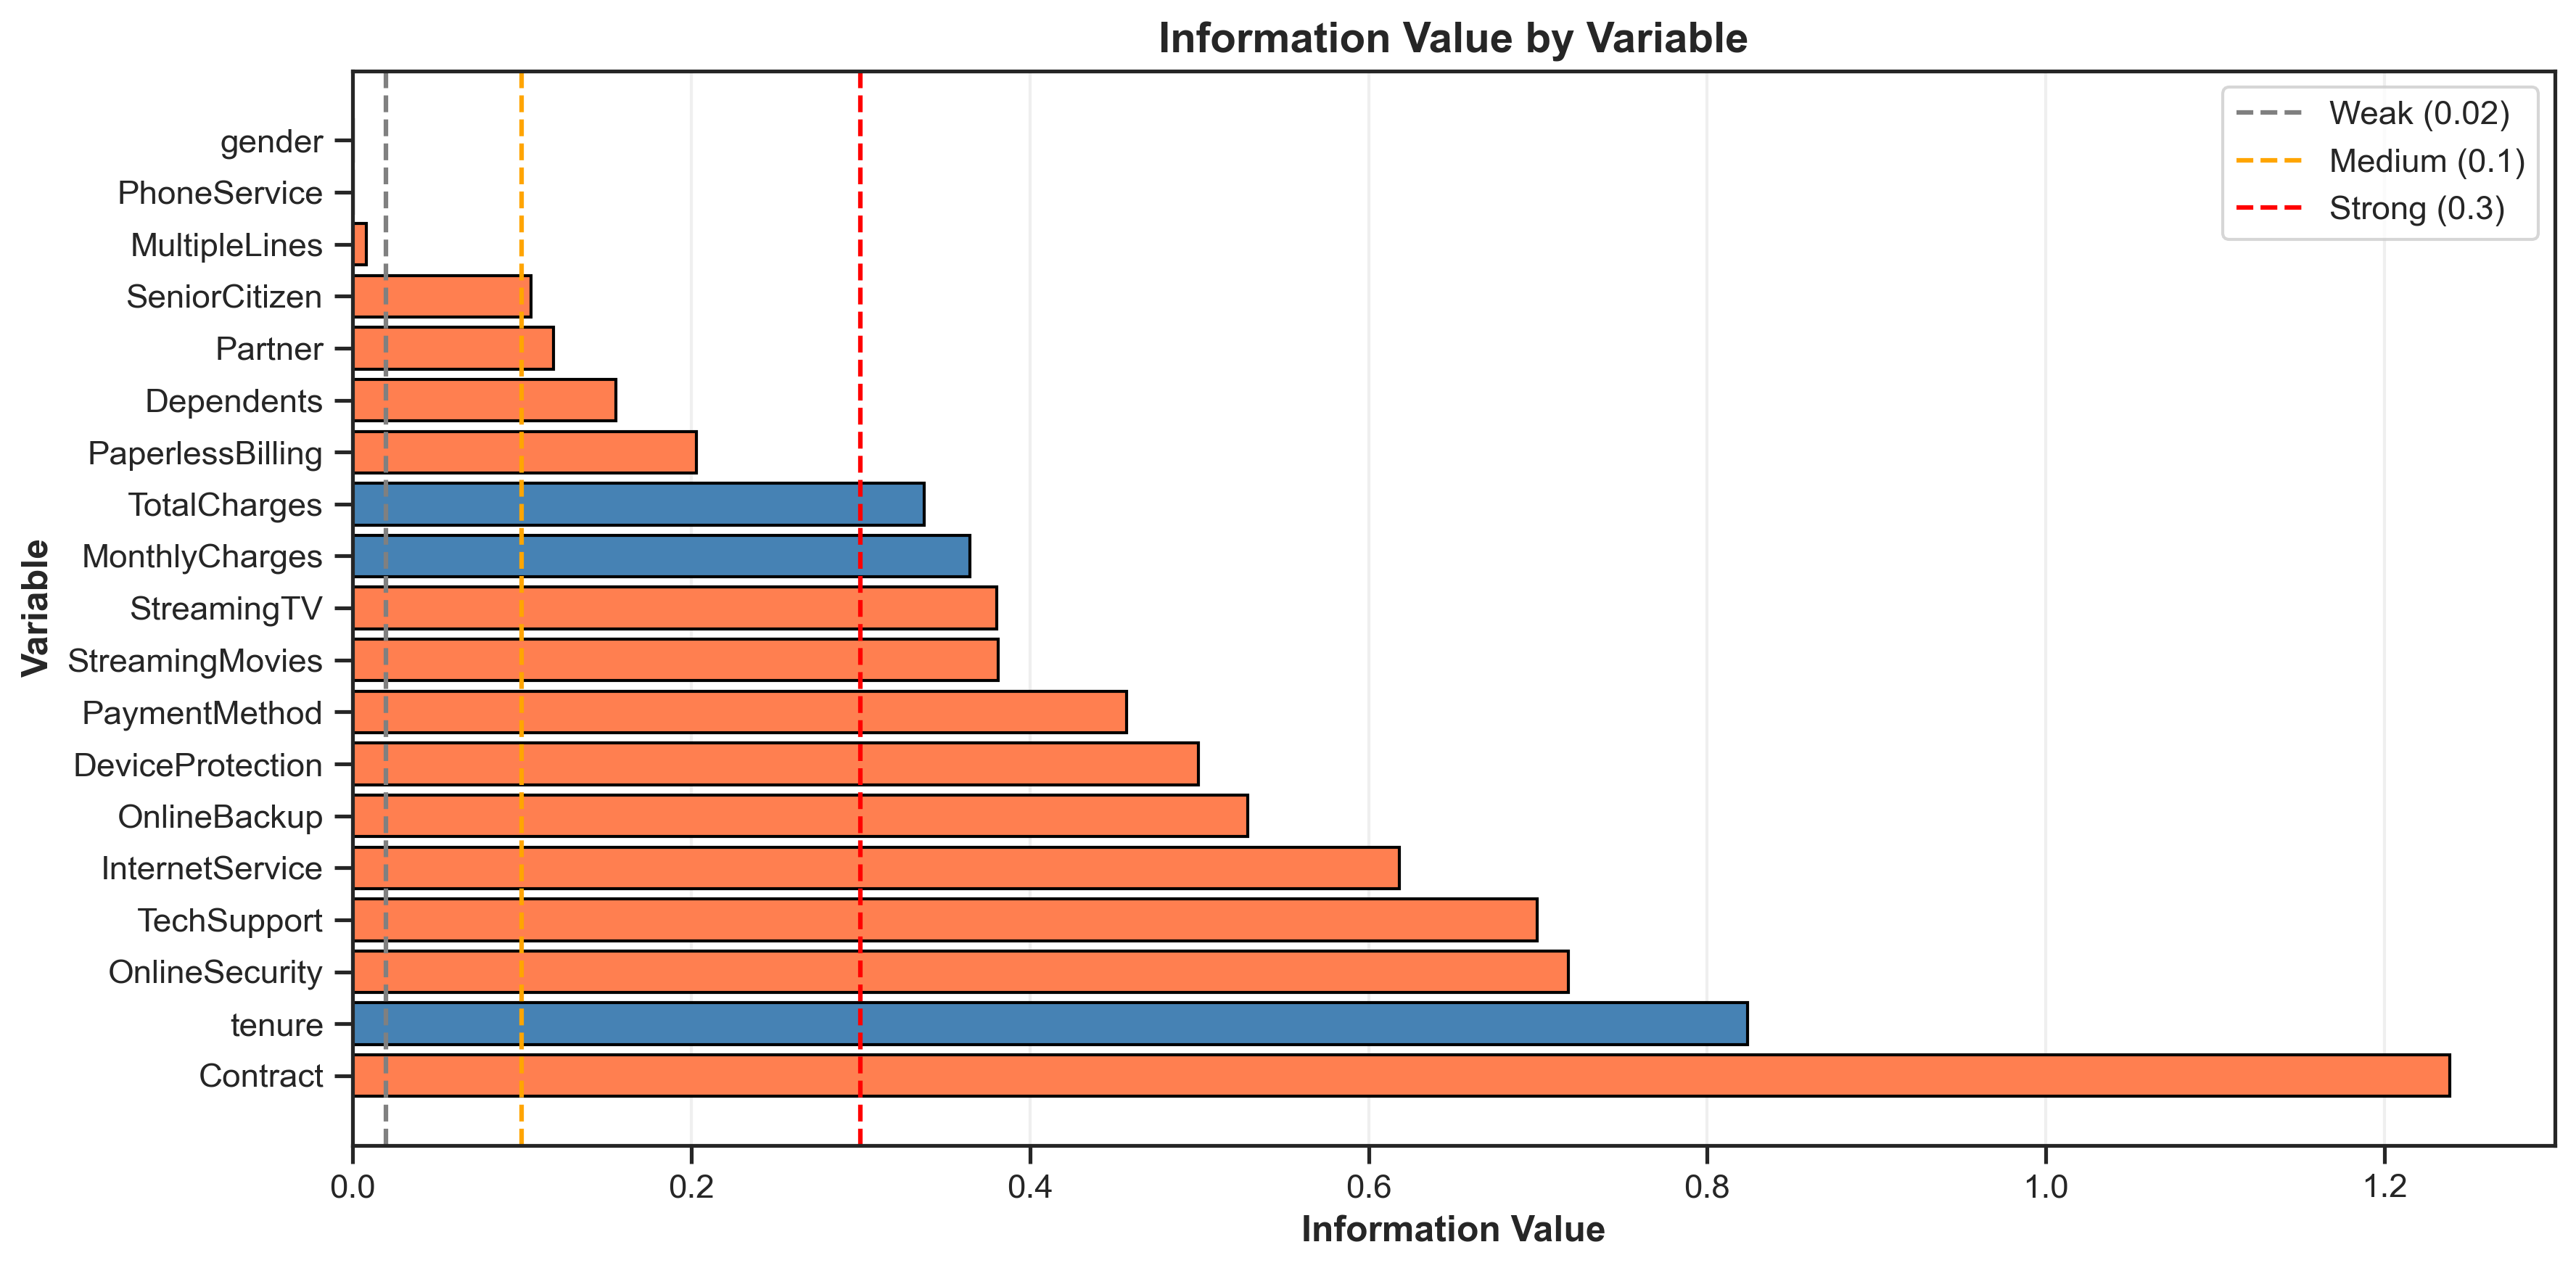

In [20]:
# Information Value 계산 함수
def calculate_iv(df, feature, target):
    # 타겟이 문자열이면 숫자로 변환
    df_temp = df.copy()
    if df_temp[target].dtype == 'object':
        df_temp[target] = df_temp[target].map({'Yes': 1, 'No': 0})
    
    # 수치형 변수는 구간으로 나누기 (binning)
    if df_temp[feature].dtype in ['int64', 'float64']:
        # 결측치가 있으면 제거
        df_temp = df_temp[[feature, target]].dropna()
        # 10개 구간으로 나누기
        df_temp[feature + '_bin'] = pd.qcut(df_temp[feature], q=10, duplicates='drop')
        feature_col = feature + '_bin'
    else:
        feature_col = feature
    
    # 각 범주별 Good(0)과 Bad(1) 개수 계산
    grouped = df_temp.groupby(feature_col)[target].agg(['sum', 'count'])
    grouped.columns = ['Bad', 'Total']
    grouped['Good'] = grouped['Total'] - grouped['Bad']
    
    # 전체 Good, Bad 개수
    total_good = grouped['Good'].sum()
    total_bad = grouped['Bad'].sum()
    
    # WOE와 IV 계산
    grouped['Good_pct'] = grouped['Good'] / total_good
    grouped['Bad_pct'] = grouped['Bad'] / total_bad
    
    # 0 방지 (작은 값 추가)
    grouped['Good_pct'] = grouped['Good_pct'].replace(0, 0.0001)
    grouped['Bad_pct'] = grouped['Bad_pct'].replace(0, 0.0001)
    
    # WOE = ln(Good% / Bad%)
    grouped['WOE'] = np.log(grouped['Good_pct'] / grouped['Bad_pct'])
    
    # IV = (Good% - Bad%) * WOE
    grouped['IV'] = (grouped['Good_pct'] - grouped['Bad_pct']) * grouped['WOE']
    
    iv_total = grouped['IV'].sum()
    
    return iv_total

# 모든 변수에 대해 IV 계산
print("=== Information Value (변수 중요도) ===\n")

iv_results = []

# 수치형 변수
for col in numeric_cols:
    try:
        iv = calculate_iv(df, col, 'Churn')
        iv_results.append({'변수': col, 'IV': round(iv, 4), '타입': '수치형'})
    except:
        pass

# 범주형 변수 (customerID 제외)
for col in categorical_cols:
    try:
        iv = calculate_iv(df, col, 'Churn')
        iv_results.append({'변수': col, 'IV': round(iv, 4), '타입': '범주형'})
    except:
        pass

# 결과 정리
iv_df = pd.DataFrame(iv_results).sort_values('IV', ascending=False)
print(iv_df)

# 시각화
plt.figure(figsize=(12, 6))
colors = ['steelblue' if x == '수치형' else 'coral' for x in iv_df['타입']]
plt.barh(iv_df['변수'], iv_df['IV'], color=colors, edgecolor='black')
plt.xlabel('Information Value', fontweight='bold')
plt.ylabel('Variable', fontweight='bold')
plt.title('Information Value by Variable', fontsize=14, fontweight='bold')
plt.axvline(x=0.02, color='gray', linestyle='--', label='Weak (0.02)')
plt.axvline(x=0.1, color='orange', linestyle='--', label='Medium (0.1)')
plt.axvline(x=0.3, color='red', linestyle='--', label='Strong (0.3)')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 3.데이터 전처리

### 3-1. 결측치 처리

In [21]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [22]:
# 결측치 데이터 확인
df[np.isnan(df['TotalCharges'])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,Not Senior,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,Not Senior,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,Not Senior,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,Not Senior,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,Not Senior,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,Not Senior,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,Not Senior,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,Not Senior,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,Not Senior,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,Not Senior,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [23]:
# TotalCharges의 결측치는 신규가입 고객 -> 결측치 0으로 처리
df['TotalCharges'] = df['TotalCharges'].replace(np.nan, 0)

In [24]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 3-2. 이상치 처리

- Telco 데이터에는 실제 이상치가 없으므로 처리가 불필요
- 하지만 선택에 따라 제거, 로그 변환, 구간화 등의 방법을 시도해볼 수 있음


### 3-3. 문자형 데이터 라벨인코딩

In [25]:
df_processed = df.copy()
df_processed = df_processed.drop('customerID', axis=1)

y = df_processed['Churn'].map({'Yes': 1, 'No': 0})
df_processed = df_processed.drop('Churn', axis=1)

categorical_cols = df_processed.select_dtypes(include='object').columns.tolist()

df_encoded = df_processed.copy()
le = LabelEncoder()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    unique_values = df_processed[col].unique()[:3]
    encoded_values = le.fit(df_processed[col]).transform(unique_values)
    

df_encoded.dtypes.value_counts()

int64      17
float64     2
Name: count, dtype: int64

In [26]:
df_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65


### 3-4. 수치형 데이터 스케일링

In [27]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

X = df_encoded
y = y


In [28]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,-1.277445,0,1,0,0,2,0,0,0,0,0,1,2,-1.160323,-0.992611
1,1,0,0,0,0.066327,1,0,0,2,0,2,0,0,0,1,0,3,-0.259629,-0.172165
2,1,0,0,0,-1.236724,1,0,0,2,2,0,0,0,0,0,1,3,-0.362660,-0.958066
3,1,0,0,0,0.514251,0,1,0,2,0,2,2,0,0,1,0,0,-0.746535,-0.193672
4,0,0,0,0,-1.236724,1,0,1,0,0,0,0,0,0,0,1,2,0.197365,-0.938874
